<a href="https://colab.research.google.com/github/AbderrahmenHachicha/CardioDiffusion/blob/main/notebooks/02_ddpm_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_ecg = pd.read_csv('/content/drive/MyDrive/Projet PFA/1_Data/processed/ecg_segments.csv')
print('DataFrame shape:', df_ecg.shape)
print('\nDataFrame head:')
display(df_ecg.head())

DataFrame shape: (111328, 189)

DataFrame head:


,segment_0,segment_1,segment_2,segment_3,segment_4,segment_5,segment_6,segment_7,segment_8,segment_9,...,segment_179,segment_180,segment_181,segment_182,segment_183,segment_184,segment_185,segment_186,label,patient
0,961,962,963,963,962,964,963,966,964,964,...,938,938,940,938,934,933,934,937,N,100
1,954,954,956,958,955,955,953,954,956,958,...,940,940,939,941,941,942,937,938,N,100
2,953,953,953,949,947,953,952,953,952,952,...,949,951,947,948,946,949,949,951,N,100
3,948,952,952,955,955,954,953,955,958,958,...,934,935,934,937,935,930,933,932,N,100
4,958,958,958,956,956,956,959,959,959,955,...,939,942,942,940,938,935,936,937,N,100


In [ ]:
print(df_ecg.shape)
print(df_ecg['label'].value_counts())

(111328, 189)
label
N    75033
L     8073
R     7257
V     7129
/     7027
A     2546
f      982
F      802
~      614
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
Name: count, dtype: int64


In [4]:
keep = ['N', 'V', 'A', 'L', 'R']
df_ecg = df_ecg[df_ecg['label'].isin(keep)]
print(df_ecg.shape)
print(df_ecg['label'].value_counts())

(100038, 189)
label
N    75033
L     8073
R     7257
V     7129
A     2546
Name: count, dtype: int64


In [5]:
label_map={"N" : 0 , "A" : 1,"V" : 2 ,"L" : 3, "R":4 }
df_ecg['label'] = df_ecg['label'].map(label_map)
print(df_ecg['label'].value_counts())

label
0    75033
3     8073
4     7257
2     7129
1     2546
Name: count, dtype: int64


In [6]:
def normalize(df):
    df_signals = df.iloc[:, :187]
    df_norm = df_signals.apply(lambda row: (row - row.min()) / (row.max() - row.min()), axis=1)
    return df_norm

In [7]:
df_norm = normalize(df_ecg)
print(df_norm.min().min())
print(df_norm.max().max())

0.0
1.0


In [8]:
from torch.utils.data import Dataset
class ECGDataset(Dataset):
  def __init__(self,signals,labels):
    signals_tansor = torch.tensor(signals.values , dtype=torch.float32)
    labels_tansor = torch.tensor(labels.values , dtype=torch.long)
    self.signals_tansor = signals_tansor
    self.labels_tansor = labels_tansor
  def __len__(self):
    return len(self.signals_tansor)
  def __getitem__(self , idx):
    return self.signals_tansor[idx], self.labels_tansor[idx]

In [9]:
dataset = ECGDataset(df_norm, df_ecg['label'])
print(len(dataset))
print(dataset[0])

100038
(tensor([0.1492, 0.1525, 0.1559, 0.1559, 0.1525, 0.1593, 0.1559, 0.1661, 0.1593,
        0.1593, 0.1559, 0.1559, 0.1661, 0.1729, 0.1627, 0.1559, 0.1492, 0.1559,
        0.1627, 0.1661, 0.1729, 0.1797, 0.1763, 0.1763, 0.1797, 0.1932, 0.1932,
        0.1898, 0.2102, 0.2136, 0.2237, 0.2271, 0.2237, 0.2169, 0.2068, 0.2136,
        0.2102, 0.2102, 0.2102, 0.2068, 0.2034, 0.2000, 0.2034, 0.2136, 0.2203,
        0.2237, 0.1966, 0.1695, 0.1695, 0.1593, 0.1525, 0.1390, 0.1390, 0.1424,
        0.1492, 0.1458, 0.1492, 0.1424, 0.1322, 0.1288, 0.1322, 0.1322, 0.1254,
        0.1288, 0.1220, 0.1390, 0.1356, 0.1390, 0.1458, 0.1288, 0.1220, 0.1322,
        0.1390, 0.1424, 0.1390, 0.1254, 0.1153, 0.1186, 0.1051, 0.0746, 0.0610,
        0.0407, 0.0169, 0.0000, 0.0203, 0.0814, 0.1593, 0.2542, 0.3525, 0.5220,
        0.6949, 0.8508, 0.9559, 1.0000, 0.9763, 0.8746, 0.6949, 0.4746, 0.2881,
        0.1797, 0.0983, 0.0576, 0.0407, 0.0542, 0.0746, 0.0983, 0.0983, 0.1017,
        0.0983, 0.1051, 0.1051, 

In [13]:
from torch.utils.data import DataLoader
dataloader = DataLoader(dataset , batch_size=64 , shuffle=True)

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class UNet1D(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512)

        # Decoder
        self.dec3 = ConvBlock(512 + 256, 256)
        self.dec2 = ConvBlock(256 + 128, 128)
        self.dec1 = ConvBlock(128 + 64, 64)

        # Output
        self.output = nn.Conv1d(64, 1, kernel_size=1)

        # Timestep embedding
        self.time_embed = nn.Embedding(1000, 187)

        # Label embedding
        self.label_embed = nn.Embedding(num_classes, 187)

    def forward(self, x, t, label):
        # Add timestep and label info
        t_emb = self.time_embed(t).unsqueeze(1)
        l_emb = self.label_embed(label).unsqueeze(1)
        x = x + t_emb + l_emb

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        # Bottleneck
        b = self.bottleneck(e3)

        # Decoder
        d3 = self.dec3(torch.cat([b, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        d1 = self.dec1(torch.cat([d2, e1], dim=1))

        return self.output(d1)

In [14]:
model = UNet1D(num_classes=5)
print(model)

UNet1D(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (enc3): ConvBlock(
    (block): Sequential(
      (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv1d(256, 512, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (dec3): ConvBlock(
    (block): S

In [15]:
batch_signals, batch_labels = next(iter(dataloader))
batch_signals = batch_signals.unsqueeze(1)  # add channel dimension
t = torch.randint(0, 1000, (batch_signals.shape[0],))

output = model(batch_signals, t, batch_labels)
print(output.shape)

torch.Size([64, 1, 187])


In [16]:
class DDPMScheduler:
    def __init__(self, num_timesteps=1000):
        self.num_timesteps = num_timesteps

        # beta increases from 0.0001 to 0.02 (noise schedule)
        self.betas = torch.linspace(0.0001, 0.02, num_timesteps)

        # alpha = 1 - beta
        self.alphas = 1 - self.betas

        # cumulative product of alphas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, signal, t):
        sqrt_alpha = self.alphas_cumprod[t] ** 0.5
        sqrt_one_minus_alpha = (1 - self.alphas_cumprod[t]) ** 0.5

        noise = torch.randn_like(signal)
        noisy_signal = sqrt_alpha * signal + sqrt_one_minus_alpha * noise

        return noisy_signal, noise

In [17]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class DDPMScheduler:
    def __init__(self, num_timesteps=1000):
        self.num_timesteps = num_timesteps

        # beta increases from 0.0001 to 0.02 (noise schedule)
        self.betas = torch.linspace(0.0001, 0.02, num_timesteps)

        # alpha = 1 - beta
        self.alphas = 1 - self.betas

        # cumulative product of alphas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, signal, t):
        sqrt_alpha_cumprod = self.alphas_cumprod[t] ** 0.5
        sqrt_one_minus_alpha_cumprod = (1 - self.alphas_cumprod[t]) ** 0.5

        # Reshape for broadcasting: (batch_size) -> (batch_size, 1, 1)
        sqrt_alpha_cumprod = sqrt_alpha_cumprod.unsqueeze(-1).unsqueeze(-1)
        sqrt_one_minus_alpha_cumprod = sqrt_one_minus_alpha_cumprod.unsqueeze(-1).unsqueeze(-1)

        noise = torch.randn_like(signal)
        noisy_signal = sqrt_alpha_cumprod * signal + sqrt_one_minus_alpha_cumprod * noise

        return noisy_signal, noise

scheduler = DDPMScheduler()
scheduler.betas = scheduler.betas.to(device)
scheduler.alphas = scheduler.alphas.to(device)
scheduler.alphas_cumprod = scheduler.alphas_cumprod.to(device)

# test with one batch
# Ensure batch_signals and t are on the correct device for testing
batch_signals = batch_signals.to(device)
t = torch.randint(0, 1000, (batch_signals.shape[0],)).to(device)
noisy_signals, noise = scheduler.add_noise(batch_signals, t)

print(noisy_signals.shape)
print(noise.shape)

torch.Size([64, 1, 187])
torch.Size([64, 1, 187])


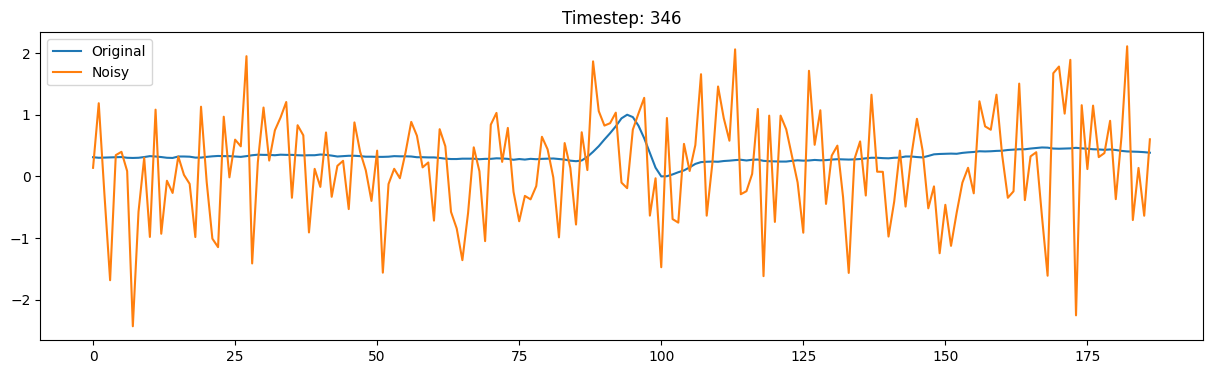

In [18]:
plt.figure(figsize=(15, 4))
plt.plot(batch_signals[0].squeeze().cpu().numpy(), label='Original')
plt.plot(noisy_signals[0].squeeze().detach().cpu().numpy(), label='Noisy')
plt.legend()
plt.title(f"Timestep: {t[0].item()}")
plt.show()

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(300):
    for batch_signals, batch_labels in dataloader:
        batch_signals = batch_signals.unsqueeze(1).to(device)
        batch_labels = batch_labels.to(device)
        t = torch.randint(0, 1000, (batch_signals.shape[0],)).to(device)
        noisy_signals, noise = scheduler.add_noise(batch_signals, t)
        predicted_noise = model(noisy_signals, t, batch_labels)
        loss = criterion(predicted_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    if (epoch + 1) % 50 == 0:
        torch.save(model.state_dict(), f'/content/drive/MyDrive/Projet PFA/3_Models/ddpm_epoch_{epoch+1}.pth')
        print(f"✅ Checkpoint saved at epoch {epoch+1}")

torch.save(model.state_dict(), '/content/drive/MyDrive/Projet PFA/3_Models/ddpm_model.pth')
print("✅ Final model saved!")

cuda
Epoch 1, Loss: 0.5928
Epoch 2, Loss: 0.3492
Epoch 3, Loss: 0.1832
Epoch 4, Loss: 0.3208
Epoch 5, Loss: 0.1339
Epoch 6, Loss: 0.0852
Epoch 7, Loss: 0.1096
Epoch 8, Loss: 0.0276
Epoch 9, Loss: 0.0410
Epoch 10, Loss: 0.0687
Epoch 11, Loss: 0.0510
Epoch 12, Loss: 0.0253
Epoch 13, Loss: 0.0335
Epoch 14, Loss: 0.0508
Epoch 15, Loss: 0.0282
Epoch 16, Loss: 0.0509
Epoch 17, Loss: 0.0301
Epoch 18, Loss: 0.0292
Epoch 19, Loss: 0.2134
Epoch 20, Loss: 0.0263
Epoch 21, Loss: 0.0153
Epoch 22, Loss: 0.0186
Epoch 23, Loss: 0.0153
Epoch 24, Loss: 0.1126
Epoch 25, Loss: 0.0223
Epoch 26, Loss: 0.0491
Epoch 27, Loss: 0.0326
Epoch 28, Loss: 0.0287
Epoch 29, Loss: 0.1796
Epoch 30, Loss: 0.0633
Epoch 31, Loss: 0.0184
Epoch 32, Loss: 0.0288
Epoch 33, Loss: 0.0287
Epoch 34, Loss: 0.0360
Epoch 35, Loss: 0.0142
Epoch 36, Loss: 0.0547
Epoch 37, Loss: 0.0335
Epoch 38, Loss: 0.0318
Epoch 39, Loss: 0.0786
Epoch 40, Loss: 0.0421
Epoch 41, Loss: 0.0290
Epoch 42, Loss: 0.0728
Epoch 43, Loss: 0.0472
Epoch 44, Loss:

In [19]:
def generate(model, scheduler, label, num_samples=10):
    model.eval()
    with torch.no_grad():
        # start with pure noise
        x = torch.randn(num_samples, 1, 187).to(device)
        labels = torch.full((num_samples,), label, dtype=torch.long).to(device)

        # reverse process
        for t in reversed(range(scheduler.num_timesteps)):
            t_batch = torch.full((num_samples,), t, dtype=torch.long).to(device)
            predicted_noise = model(x, t_batch, labels)

            alpha = scheduler.alphas[t]
            alpha_cumprod = scheduler.alphas_cumprod[t]
            beta = scheduler.betas[t]

            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1/alpha**0.5) * (x - (beta/(1-alpha_cumprod)**0.5) * predicted_noise) + beta**0.5 * noise

    return x

In [23]:
scheduler.betas = scheduler.betas.to(device)
scheduler.alphas = scheduler.alphas.to(device)
scheduler.alphas_cumprod = scheduler.alphas_cumprod.to(device)

✅ Model loaded!


In [27]:
generated = generate(model, scheduler, label=1, num_samples=10)
print(generated.shape)

torch.Size([10, 1, 187])


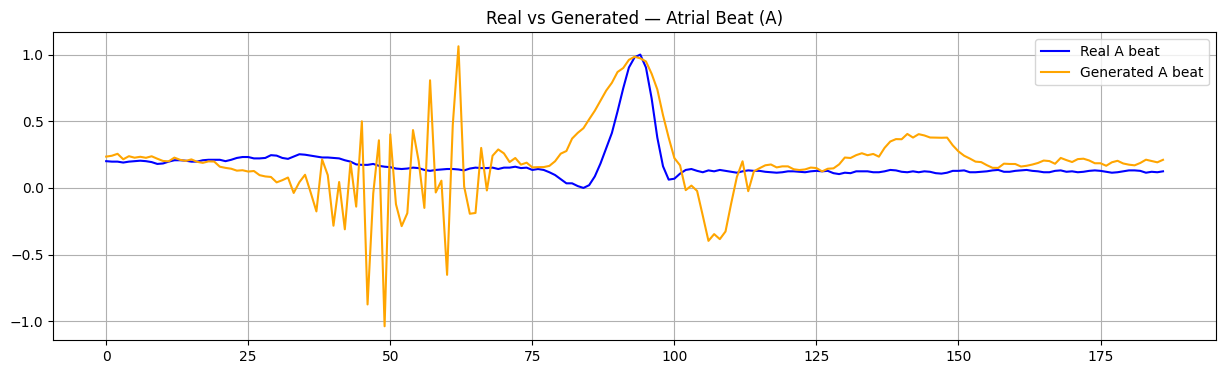

In [28]:
# Get a real A beat from dataset
real_A = df_norm[df_ecg['label'] == 1].iloc[0].values

plt.figure(figsize=(15, 4))
plt.plot(real_A, label='Real A beat', color='blue')
plt.plot(generated[0].squeeze().cpu().numpy(), label='Generated A beat', color='orange')
plt.legend()
plt.title("Real vs Generated — Atrial Beat (A)")
plt.grid(True)
plt.show()

In [29]:
all_generated = []

classes = {'N': 0, 'A': 1, 'V': 2, 'L': 3, 'R': 4}
samples_per_class = {'N': 1000, 'A': 3000, 'V': 3000, 'L': 3000, 'R': 3000}

for class_name, class_idx in classes.items():
    print(f"Generating {samples_per_class[class_name]} {class_name} beats...")
    generated = generate(model, scheduler, label=class_idx,
                        num_samples=samples_per_class[class_name])

    signals = generated.squeeze(1).cpu().numpy()

    for signal in signals:
        row = signal.tolist() + [class_name]
        all_generated.append(row)

    print(f"✅ {class_name} done!")

cols = [f"segment_{i}" for i in range(187)] + ["label"]
df_generated = pd.DataFrame(all_generated, columns=cols)
print(df_generated.shape)
print(df_generated['label'].value_counts())

Generating 1000 N beats...
✅ N done!
Generating 3000 A beats...
✅ A done!
Generating 3000 V beats...
✅ V done!
Generating 3000 L beats...
✅ L done!
Generating 3000 R beats...
✅ R done!
(13000, 188)
label
A    3000
L    3000
V    3000
R    3000
N    1000
Name: count, dtype: int64


In [30]:
df_generated.to_csv('/content/drive/MyDrive/Projet PFA/1_Data/generated/ecg_generated.csv', index=False)
print("✅ ecg_generated.csv saved!")

✅ ecg_generated.csv saved!
